# Assignment 3

## AI Statement

## Statement of AI use

I first attempted to structure and solve the assignment myself. I then used ChatGPT to help debug code, AI was especially helpful in the latter parts of the assignment where Supervised Machine Learning was introduced. Although getting critical help from AI was very helpful I found that also helped me better understand the code I was writing. I reviewed and adjusted the code before submission to make sure I understood the steps and that the notebook runs correctly.<

In [1]:
import json
import re
import time
from pathlib import Path

import pandas as pd
import requests
from IPython.display import display

### Task 0a

In [2]:
OLLAMA_BASE_URL = "http://localhost:11434/api"

SMALL_MODEL = "gemma3:270m"
LARGE_MODEL = "gemma3:4b"

DATA_DIR = Path(".")

### Task 0b

In [3]:
import os
import shutil
import subprocess

# Make sure Jupyter can find Ollama on Windows
ollama_path = shutil.which("ollama")

if ollama_path is None:
    possible_path = Path(os.environ["LOCALAPPDATA"]) / "Programs" / "Ollama" / "ollama.exe"
    
    if possible_path.exists():
        os.environ["PATH"] += os.pathsep + str(possible_path.parent)
        ollama_path = str(possible_path)

In [4]:
!ollama pull gemma3:270m

pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest 
pulling 735af2139dc6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 291 MB                         
pulling 4b19ac7dd2fb: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  476 B                         
pulling 3e2c24001f9e: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 8.4 KB                         
pulling 339e884a40f6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�   61 B                         
pulling 74156d92caf6: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  490 B                         
verifying sha256 digest 
writing manifest 
success 


In [5]:
def ollama_generate(model, prompt, response_format=None, temperature=0.2, timeout=240):
    """
    Sends a prompt to a local Ollama model and returns the response text.
    """
    payload = {
        "model": model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": temperature
        }
    }

    if response_format is not None:
        payload["format"] = response_format

    response = requests.post(
        f"{OLLAMA_BASE_URL}/generate",
        json=payload,
        timeout=timeout
    )

    response.raise_for_status()

    return response.json()["response"].strip()

In [6]:
small_test = ollama_generate(
    model=SMALL_MODEL,
    prompt="Answer in one short sentence: What is business intelligence?"
)

print(small_test)

Business intelligence (BI) is the process of analyzing and understanding business data to provide insights and actionable intelligence to inform business decisions.


### Task 0c

In [7]:
!ollama pull gemma3:4b

pulling manifest â ‹ pulling manifest â ™ pulling manifest â ¹ pulling manifest â ¸ pulling manifest â ¼ pulling manifest 
pulling aeda25e63ebd: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 3.3 GB                         
pulling e0a42594d802: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  358 B                         
pulling dd084c7d92a3: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–� 8.4 KB                         
pulling 3116c5225075: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�   77 B                         
pulling b6ae5839783f: 100% â–•â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–�  489 B                         
verifying sha256 digest 
writing manifest 
success 


In [8]:
large_test = ollama_generate(
    model=LARGE_MODEL,
    prompt="Answer in one short sentence: What is business intelligence?",
)

print(large_test)

Business intelligence is the process of analyzing data to gain insights and make better business decisions.


### Task 1a

In [9]:
## To avoid problems with possible commas in some headlines we include the following code which will treat every row after the header as one full headline
def read_headline_file(path):
    """
    Reads a one-column headline file where some headlines may contain commas.
    Each non-empty line after the first line is treated as one headline.
    """
    path = Path(path)

    lines = path.read_text(encoding="utf-8").splitlines()
    lines = [line.strip() for line in lines if line.strip()]

    if lines[0].lower() == "headline":
        lines = lines[1:]

    return pd.DataFrame({"headline": lines})

In [10]:
def extract_allowed_label(response, allowed_labels, default_label):
    """
    Cleans model output so that only one allowed label is returned.
    """
    text = response.strip().lower()
    text = text.replace("`", "").replace('"', "").replace("'", "")

    if text in allowed_labels:
        return text

    words = re.sub(r"[^a-z]", " ", text).split()

    for word in words:
        if word in allowed_labels:
            return word

    return default_label


def classify_email(headline, model=SMALL_MODEL, temperature=0.2):
    """
    Classifies an email headline as spam, work, or unknown.
    Returns only the final label.
    """
    prompt = f"""
You are classifying email headlines.

Choose exactly one of these labels:
- spam: suspicious, promotional, scam-like, or clearly unwanted
- work: clearly legitimate work-related email
- unknown: too vague to classify from the headline alone

Return only one word: spam, work, or unknown.

Headline:
{headline}

Label:
"""

    response = ollama_generate(
        model=model,
        prompt=prompt,
        temperature=temperature
    )

    return extract_allowed_label(
        response=response,
        allowed_labels=["spam", "work", "unknown"],
        default_label="unknown"
    )

In [11]:
emails = read_headline_file(DATA_DIR / "emails.csv")

display(emails)

,headline
0,URGENT: Your account will be suspended within ...
1,Congratulations! You have won a 1000€ gift car...
2,Hot singles in your area are waiting to meet y...
3,Re: Inheritance transfer of 4.5M USD pending y...
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Fr..."
6,Reminder: Annual performance review scheduled ...
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


### Task 1b

In [12]:
emails_270m = emails.copy()

emails_270m["gemma3_270m"] = [
    classify_email(headline, model=SMALL_MODEL)
    for headline in emails_270m["headline"]
]

display(emails_270m)

,headline,gemma3_270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,"Q3 budget report attached, please review by Fr...",spam
6,Reminder: Annual performance review scheduled ...,spam
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


### Task 1c

In [13]:
emails_4b = emails.copy()

emails_4b["gemma3_4b"] = [
    classify_email(headline, model=LARGE_MODEL)
    for headline in emails_4b["headline"]
]

display(emails_4b)

,headline,gemma3_4b
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift car...,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Fr...",work
6,Reminder: Annual performance review scheduled ...,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,unknown
9,Following up,unknown


The two models produced clearly different results. The smaller Gemma 270m model classified every headline as spam, which suggests that it did not understand the classification task very well. It correctly identifies the obvious spam examples, but it also incorrectly labels normal work-related emails and vague emails as spam.

The larger Gemma 4b model gives a more realistic classification. It classifies the first suspicious emails as spam, the clear office-related emails as work, and the vague emails such as "Quick question about last week", "Following up", and "Are you available?" as unknown. This is more reasonable because those headlines do not contain enough information to classify them confidently as either spam or work.

Overall, the 4b model performs better in this task. The 270m model is faster, but its answers are too unreliable for this dataset.

### Task 1d

In [14]:
email_repeat_results = emails.copy()

for run in range(1, 4):
    email_repeat_results[f"270m_run_{run}"] = [
        classify_email(headline, model=SMALL_MODEL)
        for headline in email_repeat_results["headline"]
    ]

    email_repeat_results[f"4b_run_{run}"] = [
        classify_email(headline, model=LARGE_MODEL)
        for headline in email_repeat_results["headline"]
    ]

display(email_repeat_results)

,headline,270m_run_1,4b_run_1,270m_run_2,4b_run_2,270m_run_3,4b_run_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam,spam,spam,spam
1,Congratulations! You have won a 1000€ gift car...,spam,spam,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,spam,work,spam,work,spam,work
5,"Q3 budget report attached, please review by Fr...",spam,work,spam,work,spam,work
6,Reminder: Annual performance review scheduled ...,spam,work,spam,work,spam,work
7,"Updated draft of the manuscript, comments welcome",spam,work,spam,work,spam,work
8,Quick question about last week,spam,unknown,spam,unknown,spam,unknown
9,Following up,spam,unknown,spam,unknown,spam,unknown


The repeated runs show that both models were stable, because the same headlines received the same classifications in all three runs. However, stability does not necessarily mean that the model performs well. The smaller 270m model classified every headline as spam in every run, which makes the output consistent but not very useful. It fails to separate obvious work emails and vague emails from actual spam.
The larger 4b model was also stable across the three runs, but its classifications were much more meaningful. It classified suspicious headlines as spam, clear office-related headlines as work, and vague headlines such as "Following up" or "Are you available?" as unknown.

### Task 2a

In [15]:
TOPIC_LABELS = ["earnings", "mergers", "regulation", "macroeconomics"]
SENTIMENT_LABELS = ["positive", "negative", "neutral"]

NEWS_SCHEMA = {
    "type": "object",
    "properties": {
        "topic": {
            "type": "string",
            "enum": TOPIC_LABELS
        },
        "sentiment": {
            "type": "string",
            "enum": SENTIMENT_LABELS
        }
    },
    "required": ["topic", "sentiment"],
    "additionalProperties": False
}

In [16]:
def fallback_news_classification(headline):
    """
    Used only if the model output cannot be parsed as JSON.
    This prevents the notebook from crashing.
    """
    text = headline.lower()

    if any(word in text for word in ["earnings", "profit", "revenue", "forecast", "estimates"]):
        topic = "earnings"
    elif any(word in text for word in ["merger", "acquire", "rival", "deal", "talks"]):
        topic = "mergers"
    elif any(word in text for word in ["regulator", "regulators", "act", "fsa", "licence", "compliance"]):
        topic = "regulation"
    else:
        topic = "macroeconomics"

    if any(word in text for word in ["beats", "surges", "grants", "expanded", "cools", "easing"]):
        sentiment = "positive"
    elif any(word in text for word in ["misses", "weak", "block", "raise costs", "rising", "weigh", "climb"]):
        sentiment = "negative"
    else:
        sentiment = "neutral"

    return {"topic": topic, "sentiment": sentiment}


def classify_news_headline(headline, model=LARGE_MODEL):
    """
    Classifies a financial news headline by topic and sentiment.
    Returns a dictionary with topic and sentiment.
    """
    prompt = f"""
Classify the following fictional financial news headline.

Choose exactly one topic:
- earnings
- mergers
- regulation
- macroeconomics

Choose exactly one sentiment:
- positive
- negative
- neutral

Return only valid JSON with exactly these two keys:
{{
  "topic": "...",
  "sentiment": "..."
}}

Headline:
{headline}
"""

    raw_response = ollama_generate(
        model=model,
        prompt=prompt,
        response_format=NEWS_SCHEMA,
        temperature=0,
    )

    try:
        parsed = json.loads(raw_response)
    except json.JSONDecodeError:
        return fallback_news_classification(headline)

    topic = parsed.get("topic", "").lower()
    sentiment = parsed.get("sentiment", "").lower()

    if topic not in TOPIC_LABELS or sentiment not in SENTIMENT_LABELS:
        return fallback_news_classification(headline)

    return {
        "topic": topic,
        "sentiment": sentiment
    }

### Task 2b

In [17]:
news = read_headline_file(DATA_DIR / "news.csv")

display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates...
1,Helvora Pharmaceuticals misses earnings foreca...
2,"Aurelis Bank reports steady quarterly profit, ..."
3,Veridyne Logistics to acquire rival Trantec in...
4,Antitrust regulators block proposed merger bet...
5,Kestrel Semiconductor confirms early-stage mer...
6,New EU AI Act compliance rules expected to rai...
7,Finnish FSA grants Norvik Capital expanded lic...
8,"Eurozone inflation cools to 2.1%, easing press..."
9,Rising interest rates weigh on Tessaro Real Es...


In [18]:
news_classifications = [
    classify_news_headline(headline, model=LARGE_MODEL)
    for headline in news["headline"]
]

news_results = pd.concat(
    [
        news,
        pd.DataFrame(news_classifications)
    ],
    axis=1
)

display(news_results)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,neutral
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


In [19]:
browser_prompt = f"""
Classify each of the following fictional financial news headlines.

Choose exactly one topic from:
- earnings
- mergers
- regulation
- macroeconomics

Choose exactly one sentiment from:
- positive
- negative
- neutral

Return the answer as a markdown table with columns:
headline, topic, sentiment

Headlines:
{chr(10).join("- " + headline for headline in news["headline"])}
"""

print(browser_prompt)


Classify each of the following fictional financial news headlines.

Choose exactly one topic from:
- earnings
- mergers
- regulation
- macroeconomics

Choose exactly one sentiment from:
- positive
- negative
- neutral

Return the answer as a markdown table with columns:
headline, topic, sentiment

Headlines:
- Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
- Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
- Aurelis Bank reports steady quarterly profit, in line with analyst expectations
- Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
- Antitrust regulators block proposed merger between Solenta and Marvex Energy
- Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
- New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
- Finnish FSA grants Norvik Capital expanded licence for cross-border operations
- Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings 

Claude answer:

| Headline | Topic | Sentiment |
|---|---|---|
| Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28% | earnings | positive |
| Helvora Pharmaceuticals misses earnings forecast amid weak generics demand | earnings | negative |
| Aurelis Bank reports steady quarterly profit, in line with analyst expectations | earnings | neutral |
| Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal | mergers | neutral |
| Antitrust regulators block proposed merger between Solenta and Marvex Energy | mergers | negative |
| Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG | mergers | neutral |
| New EU AI Act compliance rules expected to raise costs for Lumavex by 12% | regulation | negative |
| Finnish FSA grants Norvik Capital expanded licence for cross-border operations | regulation | positive |
| Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs | macroeconomics | positive |
| Rising interest rates weigh on Tessaro Real Estate as financing costs climb | macroeconomics | negative |

The results were mostly similar between the local Gemma model and the browser-based LLM. Both models classified the clear earnings, regulation and macroeconomic headlines in a reasonable way. For example, the earnings miss was classified as negative, inflation cooling was classified as positive, and rising interest rates were classified as negative.

The main differences appeared in borderline cases. For example, the headline about Aurelis Bank reporting steady profit could be interpreted as neutral because the result was in line with expectations, but it can also be seen as slightly positive because the company remained profitable. Similarly, the acquisition headline was classified as positive, although it could also be neutral because an acquisition announcement does not automatically mean value creation. The Finnish FSA licence headline could arguably be positive, since receiving an expanded licence is beneficial for the company.

Overall, the browser-based LLM result appears slightly more advanced, but some classifications are still debatable. The local Gemma model is useful for simple classification, but larger browser-based models may handle borderline financial news headlines better.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Task 3a

In [21]:
DATA_DIR = Path(".")

bank = pd.read_csv(DATA_DIR / "bank-additional.csv", sep=";")

display(bank.head())
print(bank.shape)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)


In [22]:
print("Rows and columns:")
print(bank.shape)

print("\nColumn names:")
print(bank.columns)

print("\nData types:")
print(bank.dtypes)

print("\nMissing values:")
display(bank.isna().sum())

Rows and columns:
(4119, 21)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

Data types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Missing values:


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [23]:
display(bank.describe())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [24]:
display(bank.describe(include="object"))

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


In [25]:
target_counts = bank["y"].value_counts()
target_percentages = bank["y"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages.round(2)
}))

,count,percentage
y,,
no,3668,89.05
yes,451,10.95


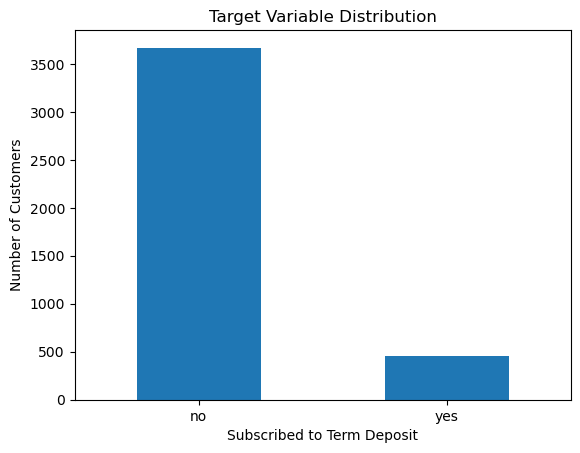

In [26]:
target_counts.plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

The dataset contains information about customers contacted during a bank marketing campaign. The target variable is `y`, which shows whether the customer subscribed to a term deposit. Since `y` has only two possible values, yes and no, the task is a binary classification problem.

The exploratory analysis shows that the dataset contains both numerical and categorical variables. The target distribution is not balanced, because most customers did not subscribe to the term deposit.

### Task 3b

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [28]:
df = bank.copy()

df["y_binary"] = df["y"].map({"no": 0, "yes": 1})

X = df.drop(columns=["y", "y_binary"])

X = X.drop(columns=["duration"])

y = df["y_binary"]

print(X.shape)
print(y.value_counts())

(4119, 19)
y_binary
0    3668
1     451
Name: count, dtype: int64


In [29]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", list(numeric_features))
print("Categorical features:", list(categorical_features))

Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [30]:
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The preprocessing separates the target variable from the explanatory variables and converts the target into a binary variable where 1 means that the customer subscribed and 0 means that the customer did not subscribe. Numerical variables are scaled, while categorical variables are transformed using one-hot encoding. This is necessary because most scikit-learn models require numerical input.

The variable `duration` is excluded because it is only known after the phone call has taken place. Including it would make the model unrealistically strong, since the goal is to predict the outcome before knowing how long the call lasted.

### Task 3c

This is a supervised binary classification task, because the goal is to predict whether a customer subscribes to a term deposit or not. The target variable `y` has two possible outcomes, `yes` and `no`. Therefore, the task is classification rather than regression.

I selected three machine learning algorithms from scikit-learn: Logistic Regression, Random Forest and Support Vector Machine.

Logistic Regression was chosen as a simple and interpretable baseline model. Random Forest was chosen because it can capture nonlinear relationships and interactions between the variables. Support Vector Machine was chosen because it is a strong classification method and can work well after categorical variables have been one-hot encoded.

In [31]:
from sklearn.model_selection import train_test_split, ParameterGrid, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

In [32]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (2471, 19)
Validation: (824, 19)
Test: (824, 19)


In [33]:
model_specs = {
    "Logistic Regression": (
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ),
        {
            "classifier__C": [0.1, 1, 10]
        }
    ),

    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),
        {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [3, 5, None],
            "classifier__min_samples_leaf": [1, 5]
        }
    ),

    "SVM": (
        SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ),
        {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"]
        }
    )
}

In [34]:
def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("classifier", model)
    ])

In [35]:
validation_results = []
validation_best_models = {}

for model_name, (model, param_grid) in model_specs.items():
    best_f1 = -1
    best_params = None

    for params in ParameterGrid(param_grid):
        pipeline = make_pipeline(clone(model))
        pipeline.set_params(**params)

        pipeline.fit(X_train, y_train)

        y_val_pred = pipeline.predict(X_val)

        val_f1 = f1_score(y_val, y_val_pred)

        validation_results.append({
            "selection_method": "Validation split",
            "model": model_name,
            "params": params,
            "validation_accuracy": accuracy_score(y_val, y_val_pred),
            "validation_precision": precision_score(y_val, y_val_pred),
            "validation_recall": recall_score(y_val, y_val_pred),
            "validation_f1": val_f1
        })

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_params = params

    # Refit the best validation model on train + validation data
    final_pipeline = make_pipeline(clone(model))
    final_pipeline.set_params(**best_params)
    final_pipeline.fit(X_train_val, y_train_val)

    validation_best_models[model_name] = final_pipeline

validation_results_df = pd.DataFrame(validation_results)

display(
    validation_results_df.sort_values(
        by="validation_f1",
        ascending=False
    )
)

,selection_method,model,params,validation_accuracy,validation_precision,validation_recall,validation_f1
4,Validation split,Random Forest,"{'classifier__max_depth': 3, 'classifier__min_...",0.870146,0.426087,0.544444,0.478049
6,Validation split,Random Forest,"{'classifier__max_depth': 3, 'classifier__min_...",0.870146,0.426087,0.544444,0.478049
10,Validation split,Random Forest,"{'classifier__max_depth': 5, 'classifier__min_...",0.868932,0.422414,0.544444,0.475728
8,Validation split,Random Forest,"{'classifier__max_depth': 5, 'classifier__min_...",0.872573,0.431193,0.522222,0.472362
3,Validation split,Random Forest,"{'classifier__max_depth': 3, 'classifier__min_...",0.871359,0.427273,0.522222,0.470000
5,Validation split,Random Forest,"{'classifier__max_depth': 3, 'classifier__min_...",0.870146,0.423423,0.522222,0.467662
7,Validation split,Random Forest,"{'classifier__max_depth': 5, 'classifier__min_...",0.868932,0.419643,0.522222,0.465347
9,Validation split,Random Forest,"{'classifier__max_depth': 5, 'classifier__min_...",0.868932,0.419643,0.522222,0.465347
15,Validation split,SVM,"{'classifier__C': 0.1, 'classifier__kernel': '...",0.871359,0.425926,0.511111,0.464646
18,Validation split,SVM,"{'classifier__C': 1, 'classifier__kernel': 'rbf'}",0.853155,0.385185,0.577778,0.462222


In [36]:
best_validation_models_summary = (
    validation_results_df
    .sort_values("validation_f1", ascending=False)
    .groupby("model")
    .head(1)
    .reset_index(drop=True)
)

display(best_validation_models_summary)

,selection_method,model,params,validation_accuracy,validation_precision,validation_recall,validation_f1
0,Validation split,Random Forest,"{'classifier__max_depth': 3, 'classifier__min_...",0.870146,0.426087,0.544444,0.478049
1,Validation split,SVM,"{'classifier__C': 0.1, 'classifier__kernel': '...",0.871359,0.425926,0.511111,0.464646
2,Validation split,Logistic Regression,{'classifier__C': 0.1},0.844660,0.371622,0.611111,0.462185


### Task 3d

In [37]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []
cv_best_models = {}

for model_name, (model, param_grid) in model_specs.items():
    pipeline = make_pipeline(clone(model))

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    )

    grid_search.fit(X_train_val, y_train_val)

    cv_results.append({
        "selection_method": "Cross-validation",
        "model": model_name,
        "best_params": grid_search.best_params_,
        "best_cv_f1": grid_search.best_score_
    })

    cv_best_models[model_name] = grid_search.best_estimator_

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.sort_values(
        by="best_cv_f1",
        ascending=False
    )
)

,selection_method,model,best_params,best_cv_f1
1,Cross-validation,Random Forest,"{'classifier__max_depth': None, 'classifier__m...",0.486757
2,Cross-validation,SVM,"{'classifier__C': 1, 'classifier__kernel': 'rbf'}",0.455543
0,Cross-validation,Logistic Regression,{'classifier__C': 0.1},0.426591


In [38]:
def evaluate_basic(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred)
    }

In [39]:
best_validation_row = best_validation_models_summary.iloc[0]
best_validation_model_name = best_validation_row["model"]
best_validation_model = validation_best_models[best_validation_model_name]

best_cv_row = cv_results_df.sort_values("best_cv_f1", ascending=False).iloc[0]
best_cv_model_name = best_cv_row["model"]
best_cv_model = cv_best_models[best_cv_model_name]

method_comparison = pd.DataFrame([
    {
        "selection_method": "Validation split",
        "model": best_validation_model_name,
        **evaluate_basic(best_validation_model, X_test, y_test)
    },
    {
        "selection_method": "Cross-validation",
        "model": best_cv_model_name,
        **evaluate_basic(best_cv_model, X_test, y_test)
    }
])

metric_cols = ["test_accuracy", "test_precision", "test_recall", "test_f1"]
method_comparison[metric_cols] = method_comparison[metric_cols].round(3)

display(method_comparison)

,selection_method,model,test_accuracy,test_precision,test_recall,test_f1
0,Validation split,Random Forest,0.848,0.374,0.578,0.454
1,Cross-validation,Random Forest,0.880,0.453,0.478,0.465


The results show that the best overall model is the Random Forest selected using cross-validation. It achieved the highest test F1-score, 0.465, and also the highest test accuracy, 0.880. Since the dataset is imbalanced, F1-score is more informative than accuracy alone because it balances precision and recall.

The Random Forest selected using a simple validation split had a slightly lower F1-score of 0.451, but it achieved a higher recall of 0.578. This means it identified more actual subscribers, but with lower precision. In contrast, the cross-validation Random Forest had better precision, meaning that when it predicted a customer would subscribe, it was more often correct.

Overall, cross-validation performs better in this comparison because it gives the highest F1-score on the test set. It is also generally more reliable than a single validation split, because it evaluates the model across several different folds rather than relying on one random validation set. However, if the main goal was to identify as many potential subscribers as possible, the validation-split Random Forest could also be considered, since it has higher recall.

### Task 3e

In [40]:
def evaluate_on_test(model, X_test, y_test, model_name, selection_method):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_score)
    else:
        roc_auc = np.nan

    return {
        "selection_method": selection_method,
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_roc_auc": roc_auc
    }

In [41]:
final_comparison = []

for model_name, model in validation_best_models.items():
    final_comparison.append(
        evaluate_on_test(
            model=model,
            X_test=X_test,
            y_test=y_test,
            model_name=model_name,
            selection_method="Validation split"
        )
    )

for model_name, model in cv_best_models.items():
    final_comparison.append(
        evaluate_on_test(
            model=model,
            X_test=X_test,
            y_test=y_test,
            model_name=model_name,
            selection_method="Cross-validation"
        )
    )

final_comparison_df = pd.DataFrame(final_comparison)

final_comparison_df = final_comparison_df.sort_values(
    by="test_f1",
    ascending=False
)

metric_cols = [
    "test_accuracy",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_roc_auc"
]

final_comparison_df[metric_cols] = final_comparison_df[metric_cols].round(3)

display(final_comparison_df)

,selection_method,model,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
4,Cross-validation,Random Forest,0.880,0.453,0.478,0.465,0.776
1,Validation split,Random Forest,0.848,0.374,0.578,0.454,0.795
2,Validation split,SVM,0.843,0.364,0.578,0.446,0.763
5,Cross-validation,SVM,0.853,0.376,0.522,0.437,0.733
0,Validation split,Logistic Regression,0.831,0.342,0.589,0.433,0.780
3,Cross-validation,Logistic Regression,0.831,0.342,0.589,0.433,0.780


In [42]:
all_final_models = {}

for model_name, model in validation_best_models.items():
    all_final_models[f"Validation split - {model_name}"] = model

for model_name, model in cv_best_models.items():
    all_final_models[f"Cross-validation - {model_name}"] = model


for name, model in all_final_models.items():
    print("=" * 80)
    print(name)
    print("=" * 80)

    y_pred = model.predict(X_test)

    conf_matrix_df = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=["Actual no", "Actual yes"],
        columns=["Predicted no", "Predicted yes"]
    )

    display(conf_matrix_df)

    print(classification_report(y_test, y_pred, target_names=["no", "yes"]))

Validation split - Logistic Regression


,Predicted no,Predicted yes
Actual no,632,102
Actual yes,37,53


              precision    recall  f1-score   support

          no       0.94      0.86      0.90       734
         yes       0.34      0.59      0.43        90

    accuracy                           0.83       824
   macro avg       0.64      0.72      0.67       824
weighted avg       0.88      0.83      0.85       824

Validation split - Random Forest


,Predicted no,Predicted yes
Actual no,647,87
Actual yes,38,52


              precision    recall  f1-score   support

          no       0.94      0.88      0.91       734
         yes       0.37      0.58      0.45        90

    accuracy                           0.85       824
   macro avg       0.66      0.73      0.68       824
weighted avg       0.88      0.85      0.86       824

Validation split - SVM


...

              precision    recall  f1-score   support

          no       0.94      0.86      0.90       734
         yes       0.34      0.59      0.43        90

    accuracy                           0.83       824
   macro avg       0.64      0.72      0.67       824
weighted avg       0.88      0.83      0.85       824

Cross-validation - Random Forest


,Predicted no,Predicted yes
Actual no,682,52
Actual yes,47,43


              precision    recall  f1-score   support

          no       0.94      0.93      0.93       734
         yes       0.45      0.48      0.46        90

    accuracy                           0.88       824
   macro avg       0.69      0.70      0.70       824
weighted avg       0.88      0.88      0.88       824

Cross-validation - SVM


,Predicted no,Predicted yes
Actual no,656,78
Actual yes,43,47


              precision    recall  f1-score   support

          no       0.94      0.89      0.92       734
         yes       0.38      0.52      0.44        90

    accuracy                           0.85       824
   macro avg       0.66      0.71      0.68       824
weighted avg       0.88      0.85      0.86       824



The models were evaluated using accuracy, precision, recall, F1-score and confusion matrices. Since the dataset is imbalanced, with many more `no` observations than `yes` observations, accuracy alone is not sufficient. The most important class is the `yes` class, because the goal is to identify customers who are likely to subscribe to a term deposit. Therefore, precision, recall and F1-score for the `yes` class are especially important.

The Logistic Regression model achieved an accuracy of 0.83 and a recall of 0.59 for the `yes` class. This means it identified 59% of actual subscribers, but its precision was only 0.34, meaning many of its positive predictions were incorrect. The validation-split Random Forest improved the accuracy to 0.85 and achieved a `yes` class F1-score of 0.45. The validation-split SVM performed similarly, with an accuracy of 0.84 and a `yes` class F1-score of 0.45.

The best overall model was the Random Forest selected using cross-validation. It achieved the highest accuracy, 0.88, and the highest weighted average F1-score, 0.88. For the `yes` class, it achieved the highest precision, 0.45, and the highest F1-score, 0.46. This means that although it identified slightly fewer actual subscribers than some other models, its positive predictions were more reliable. It also produced fewer false positives than the other models, with only 52 non-subscribers incorrectly classified as subscribers.